# Model Setup & Training

## Project Context
This notebook trains and evaluates classification models on both datasets prepared in Notebook 03:
1. **Pathway A (Feature Selection):** `dataset_for_modeling_features.csv` — interpretable features for business insights.
2. **Pathway B (PCA):** `dataset_for_modeling_pca.csv` — dimensionality-reduced features for performance comparison.

**Models evaluated:**
- Logistic Regression
- Random Forest
- Gradient Boosting (XGBoost)

**Key considerations:**
- The target is imbalanced (~26.5% churn), so we use **stratified splits** and evaluate with **F1-score**, **Precision**, **Recall**, and **AUC-ROC** alongside accuracy.
- We apply **SMOTE** on the training set only to address class imbalance without leaking information into the test set.

**Note:** Detailed performance analysis, hyperparameter tuning, and remodelling will follow in subsequent notebooks.

In [1]:
#Import fundamental libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Import Machine Learning tools
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score, roc_auc_score, accuracy_score,
    roc_curve
)
from imblearn.over_sampling import SMOTE

#Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("All libraries imported successfully.")

All libraries imported successfully.


## 1. Load Datasets & Prepare Train/Test Splits

We load both pathway datasets, encode the target variable (`Churn`) as binary (Yes=1, No=0), and create stratified 80/20 train-test splits. SMOTE is then applied **only** to the training sets to balance the class distribution.

**Dataset dimensions:**
- **Pathway A (Features):** 7,043 rows × 30 columns (29 features + target)
- **Pathway B (PCA):** 7,043 rows × 16 columns (15 principal components + target)

**Class imbalance:** The target distribution confirms a significant imbalance — 73.5% non-churners vs. 26.5% churners. This justifies the use of SMOTE and the focus on F1-Score and AUC-ROC over raw accuracy.

**Split & SMOTE results:**
- The stratified split produced **5,634 training** and **1,409 test** samples, preserving the original class ratio in both sets.
- SMOTE upsampled the minority class (churn) in the training set from **1,495 to 4,139** samples, creating a perfectly balanced 50/50 training distribution. Importantly, the test set remains untouched to simulate real-world conditions.

In [2]:
#Load both datasets
df_features = pd.read_csv("dataset_for_modeling_features.csv")
df_pca = pd.read_csv("dataset_for_modeling_pca.csv")

print(f"Pathway A (Features) shape: {df_features.shape}")
print(f"Pathway B (PCA) shape:      {df_pca.shape}")

#Encode target variable: Yes=1, No=0
df_features["Churn"] = df_features["Churn"].map({"Yes": 1, "No": 0})
df_pca["Churn"] = df_pca["Churn"].map({"Yes": 1, "No": 0})

print(f"\nTarget distribution:\n{df_features['Churn'].value_counts(normalize=True).round(4)}")

Pathway A (Features) shape: (7043, 30)
Pathway B (PCA) shape:      (7043, 16)

Target distribution:
Churn
0    0.7346
1    0.2654
Name: proportion, dtype: float64


In [3]:
#Separate features and target for both pathways
X_feat = df_features.drop(columns=["Churn"])
y_feat = df_features["Churn"]

X_pca = df_pca.drop(columns=["Churn"])
y_pca = df_pca["Churn"]

#Stratified 80/20 train-test split (same random state for reproducibility)
RANDOM_STATE = 42

X_feat_train, X_feat_test, y_feat_train, y_feat_test = train_test_split(
    X_feat, y_feat, test_size=0.2, stratify=y_feat, random_state=RANDOM_STATE
)

X_pca_train, X_pca_test, y_pca_train, y_pca_test = train_test_split(
    X_pca, y_pca, test_size=0.2, stratify=y_pca, random_state=RANDOM_STATE
)

print(f"Pathway A — Train: {X_feat_train.shape[0]}, Test: {X_feat_test.shape[0]}")
print(f"Pathway B — Train: {X_pca_train.shape[0]}, Test: {X_pca_test.shape[0]}")

Pathway A — Train: 5634, Test: 1409
Pathway B — Train: 5634, Test: 1409


In [4]:
#Apply SMOTE to training sets only (prevents data leakage into test set)
smote = SMOTE(random_state=RANDOM_STATE)

X_feat_train_sm, y_feat_train_sm = smote.fit_resample(X_feat_train, y_feat_train)
X_pca_train_sm, y_pca_train_sm = smote.fit_resample(X_pca_train, y_pca_train)

print("SMOTE applied to training sets only.\n")
print(f"Pathway A — Before SMOTE: {y_feat_train.value_counts().to_dict()}")
print(f"Pathway A — After SMOTE:  {y_feat_train_sm.value_counts().to_dict()}\n")
print(f"Pathway B — Before SMOTE: {y_pca_train.value_counts().to_dict()}")
print(f"Pathway B — After SMOTE:  {y_pca_train_sm.value_counts().to_dict()}")

SMOTE applied to training sets only.

Pathway A — Before SMOTE: {0: 4139, 1: 1495}
Pathway A — After SMOTE:  {0: 4139, 1: 4139}

Pathway B — Before SMOTE: {0: 4139, 1: 1495}
Pathway B — After SMOTE:  {0: 4139, 1: 4139}


## 2. Define Models & Evaluation Framework

We define the three models with sensible baseline configurations and create a reusable evaluation function that computes all key metrics. This function will be used consistently across both pathways.

In [5]:
#Define model configurations
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        use_label_encoder=False
    )
}

def evaluate_model(model, X_test, y_test):
    """Evaluate a trained model and return a dictionary of key metrics."""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_proba)
    }

print("Models and evaluation framework defined.")

Models and evaluation framework defined.


## 3. Pathway A — Train & Evaluate on Feature-Selected Data

This pathway uses the interpretable feature set (29 features). Results here will support business insights and actionable recommendations.

**Results Summary:**

| Model | Accuracy | Precision | Recall | F1-Score | AUC-ROC |
|---|---|---|---|---|---|
| Logistic Regression | 0.7417 | 0.5088 | **0.7701** | **0.6128** | **0.8370** |
| Random Forest | **0.7779** | **0.5801** | 0.5909 | 0.5854 | 0.8171 |
| XGBoost | 0.7771 | 0.5785 | 0.5909 | 0.5847 | 0.8236 |

**Key observations:**
- **Logistic Regression** achieves the highest F1-Score (0.6128) and AUC-ROC (0.8370), driven by its strong Recall of 77% — it correctly identifies over 3 out of 4 actual churners. However, this comes at the cost of lower Precision (0.51), meaning roughly half of its churn predictions are false alarms.
- **Random Forest and XGBoost** produce nearly identical results, both favouring Precision (~0.58) over Recall (~0.59). They miss more churners but are more confident when they do flag someone.
- The confusion matrices show that Logistic Regression has significantly fewer False Negatives (missed churners) than the tree-based models, which is preferable in a churn prevention context where failing to identify at-risk customers is costly.
- All three ROC curves sit well above the diagonal, confirming that every model has meaningful discriminatory power. Logistic Regression's curve dominates slightly at most thresholds.

In [6]:
#Train and evaluate all models on Pathway A (Feature Selection)
results_feat = {}
trained_models_feat = {}

for name, model in models.items():
    print(f"Training {name} on Pathway A...")
    model.fit(X_feat_train_sm, y_feat_train_sm)
    trained_models_feat[name] = model
    results_feat[name] = evaluate_model(model, X_feat_test, y_feat_test)
    print(f"  ✓ {name} complete.\n")

#Display results as a DataFrame
df_results_feat = pd.DataFrame(results_feat).T.round(4)
df_results_feat.index.name = "Model"
print("=" * 60)
print("PATHWAY A — Feature Selection Results")
print("=" * 60)
df_results_feat

Training Logistic Regression on Pathway A...


  ✓ Logistic Regression complete.

Training Random Forest on Pathway A...


  ✓ Random Forest complete.

Training XGBoost on Pathway A...


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:17:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  ✓ XGBoost complete.

PATHWAY A — Feature Selection Results


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Model,,,,,
Logistic Regression,0.7417,0.5088,0.7701,0.6128,0.8370
Random Forest,0.7779,0.5801,0.5909,0.5854,0.8171
XGBoost,0.7771,0.5785,0.5909,0.5847,0.8236


In [7]:
#Classification Reports for Pathway A
for name, model in trained_models_feat.items():
    y_pred = model.predict(X_feat_test)
    print(f"\n{'=' * 50}")
    print(f"Classification Report — {name} (Pathway A)")
    print(f"{'=' * 50}")
    print(classification_report(y_feat_test, y_pred, target_names=["No Churn", "Churn"]))


Classification Report — Logistic Regression (Pathway A)
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1035
       Churn       0.51      0.77      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.74      0.75      1409


Classification Report — Random Forest (Pathway A)
              precision    recall  f1-score   support

    No Churn       0.85      0.85      0.85      1035
       Churn       0.58      0.59      0.59       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409


Classification Report — XGBoost (Pathway A)
              precision    recall  f1-score   support

    No Churn       0.85      0.84      0.85      1035
       Churn       0.58      0.59      0.58       374

    accuracy                 

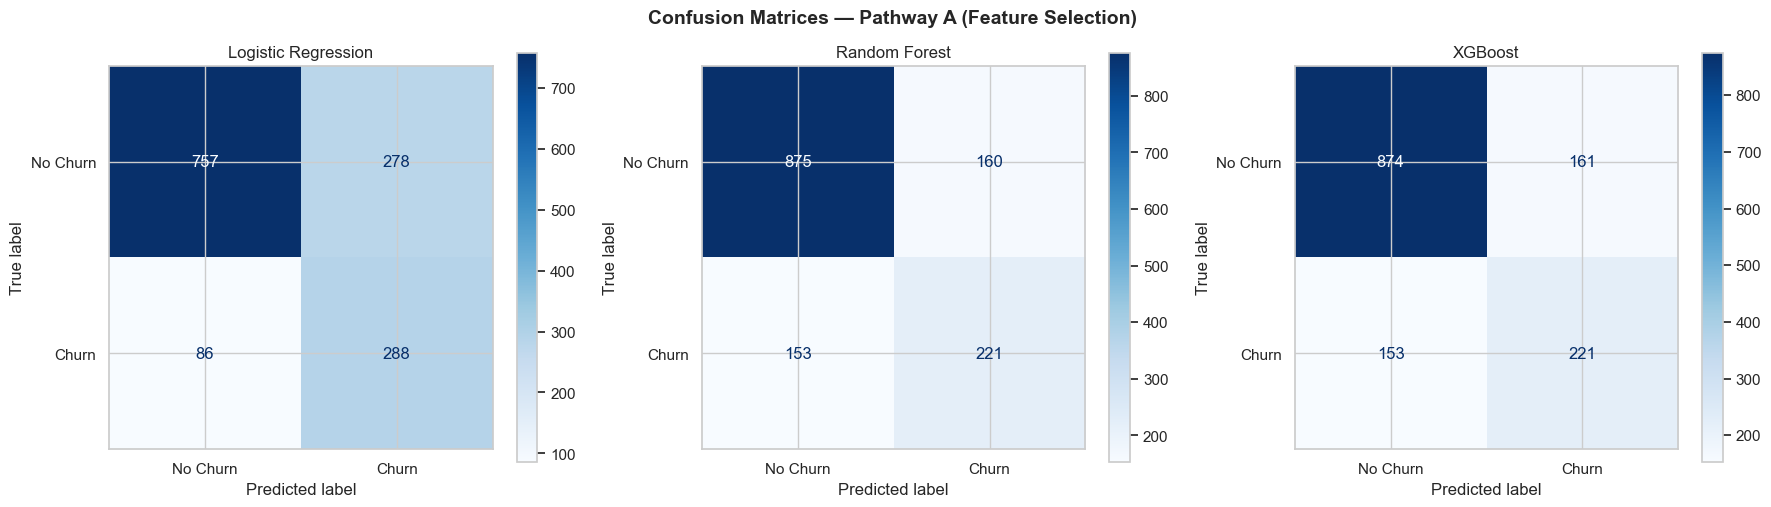

In [8]:
#Confusion Matrices for Pathway A
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices — Pathway A (Feature Selection)", fontsize=14, fontweight="bold")

for ax, (name, model) in zip(axes, trained_models_feat.items()):
    y_pred = model.predict(X_feat_test)
    ConfusionMatrixDisplay.from_predictions(
        y_feat_test, y_pred,
        display_labels=["No Churn", "Churn"],
        cmap="Blues",
        ax=ax
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

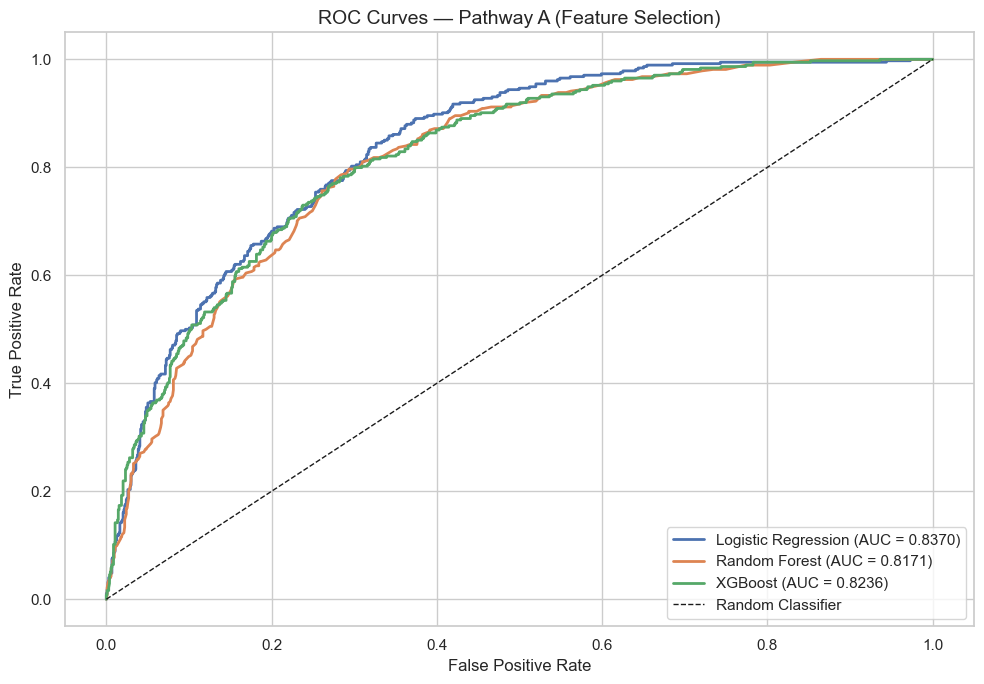

In [9]:
#ROC Curves for Pathway A
plt.figure(figsize=(10, 7))

for name, model in trained_models_feat.items():
    y_proba = model.predict_proba(X_feat_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_feat_test, y_proba)
    auc = roc_auc_score(y_feat_test, y_proba)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc:.4f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier")
plt.title("ROC Curves — Pathway A (Feature Selection)", fontsize=14)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend(loc="lower right", fontsize=11)
plt.tight_layout()
plt.show()

## 4. Pathway B — Train & Evaluate on PCA Data

This pathway uses the PCA-reduced feature set (15 principal components retaining 90% of the original variance). Results here allow us to assess whether dimensionality reduction improves or degrades model performance compared to Pathway A.

**Results Summary:**

| Model | Accuracy | Precision | Recall | F1-Score | AUC-ROC |
|---|---|---|---|---|---|
| Logistic Regression | 0.7374 | 0.5036 | **0.7567** | **0.6047** | **0.8286** |
| Random Forest | **0.7516** | **0.5299** | 0.5695 | 0.5490 | 0.7920 |
| XGBoost | 0.7523 | 0.5271 | 0.6497 | 0.5820 | 0.8099 |

**Key observations:**
- The same ranking holds as Pathway A: **Logistic Regression leads** on F1 (0.6047) and AUC-ROC (0.8286), while Random Forest and XGBoost achieve higher Accuracy but lower Recall.
- Compared to Pathway A, **every model performs worse on PCA data** across nearly all metrics. The 10% of variance lost through PCA clearly contained predictive signal that matters for churn classification.
- The most notable drop is in **Random Forest**, which loses 3.65 percentage points in F1-Score (0.5854 → 0.5490) and 2.51 points in AUC-ROC (0.8171 → 0.7920). Tree-based models rely on feature splits, and PCA's linear combinations obscure the natural decision boundaries.
- XGBoost is the only model where PCA yields higher Recall (0.6497 vs. 0.5909), but this is offset by a substantial drop in Precision (0.5271 vs. 0.5785), resulting in a nearly identical F1-Score.

In [10]:
#Re-initialize models for Pathway B (fresh instances to avoid state carryover)
models_pca = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        use_label_encoder=False
    )
}

#Train and evaluate all models on Pathway B (PCA)
results_pca = {}
trained_models_pca = {}

for name, model in models_pca.items():
    print(f"Training {name} on Pathway B...")
    model.fit(X_pca_train_sm, y_pca_train_sm)
    trained_models_pca[name] = model
    results_pca[name] = evaluate_model(model, X_pca_test, y_pca_test)
    print(f"  ✓ {name} complete.\n")

#Display results as a DataFrame
df_results_pca = pd.DataFrame(results_pca).T.round(4)
df_results_pca.index.name = "Model"
print("=" * 60)
print("PATHWAY B — PCA Results")
print("=" * 60)
df_results_pca

Training Logistic Regression on Pathway B...
  ✓ Logistic Regression complete.

Training Random Forest on Pathway B...


  ✓ Random Forest complete.

Training XGBoost on Pathway B...


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:17:33] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  ✓ XGBoost complete.

PATHWAY B — PCA Results


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Model,,,,,
Logistic Regression,0.7374,0.5036,0.7567,0.6047,0.8286
Random Forest,0.7516,0.5299,0.5695,0.5490,0.7920
XGBoost,0.7523,0.5271,0.6497,0.5820,0.8099


In [11]:
#Classification Reports for Pathway B
for name, model in trained_models_pca.items():
    y_pred = model.predict(X_pca_test)
    print(f"\n{'=' * 50}")
    print(f"Classification Report — {name} (Pathway B)")
    print(f"{'=' * 50}")
    print(classification_report(y_pca_test, y_pred, target_names=["No Churn", "Churn"]))


Classification Report — Logistic Regression (Pathway B)
              precision    recall  f1-score   support

    No Churn       0.89      0.73      0.80      1035
       Churn       0.50      0.76      0.60       374

    accuracy                           0.74      1409
   macro avg       0.70      0.74      0.70      1409
weighted avg       0.79      0.74      0.75      1409


Classification Report — Random Forest (Pathway B)
              precision    recall  f1-score   support

    No Churn       0.84      0.82      0.83      1035
       Churn       0.53      0.57      0.55       374

    accuracy                           0.75      1409
   macro avg       0.68      0.69      0.69      1409
weighted avg       0.76      0.75      0.75      1409


Classification Report — XGBoost (Pathway B)
              precision    recall  f1-score   support

    No Churn       0.86      0.79      0.82      1035
       Churn       0.53      0.65      0.58       374

    accuracy                 

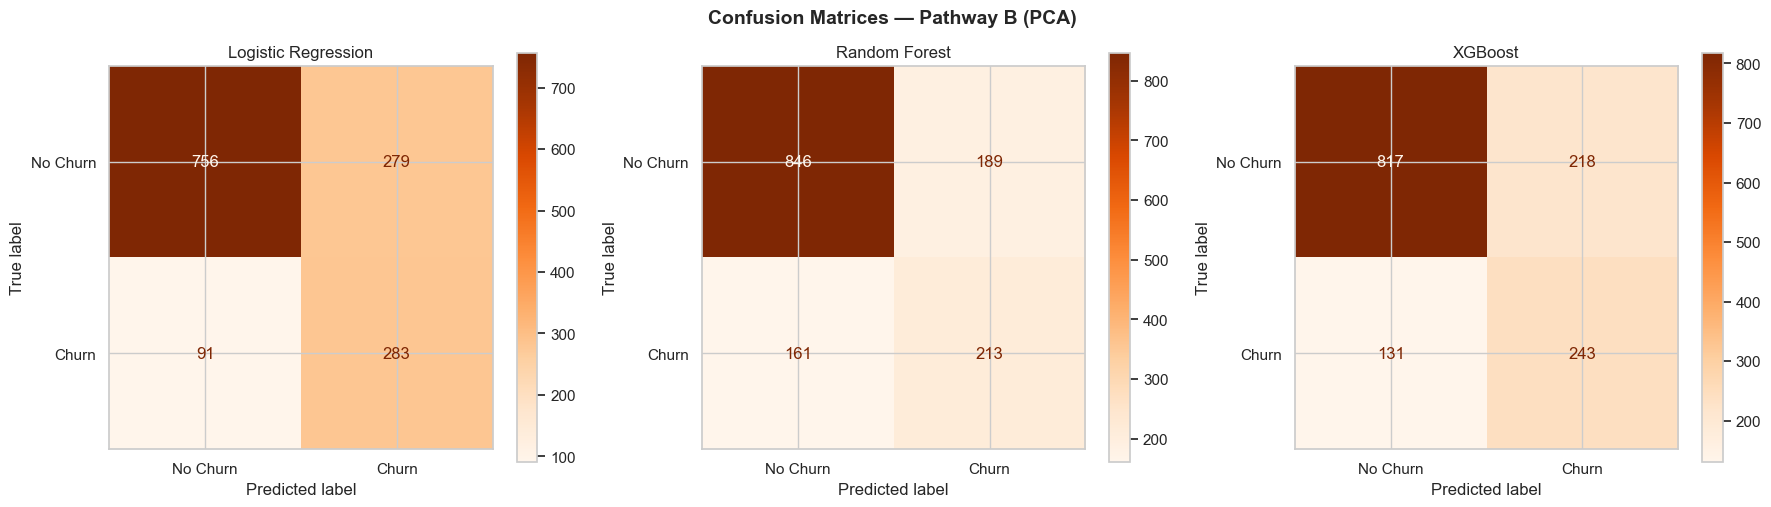

In [12]:
#Confusion Matrices for Pathway B
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices — Pathway B (PCA)", fontsize=14, fontweight="bold")

for ax, (name, model) in zip(axes, trained_models_pca.items()):
    y_pred = model.predict(X_pca_test)
    ConfusionMatrixDisplay.from_predictions(
        y_pca_test, y_pred,
        display_labels=["No Churn", "Churn"],
        cmap="Oranges",
        ax=ax
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

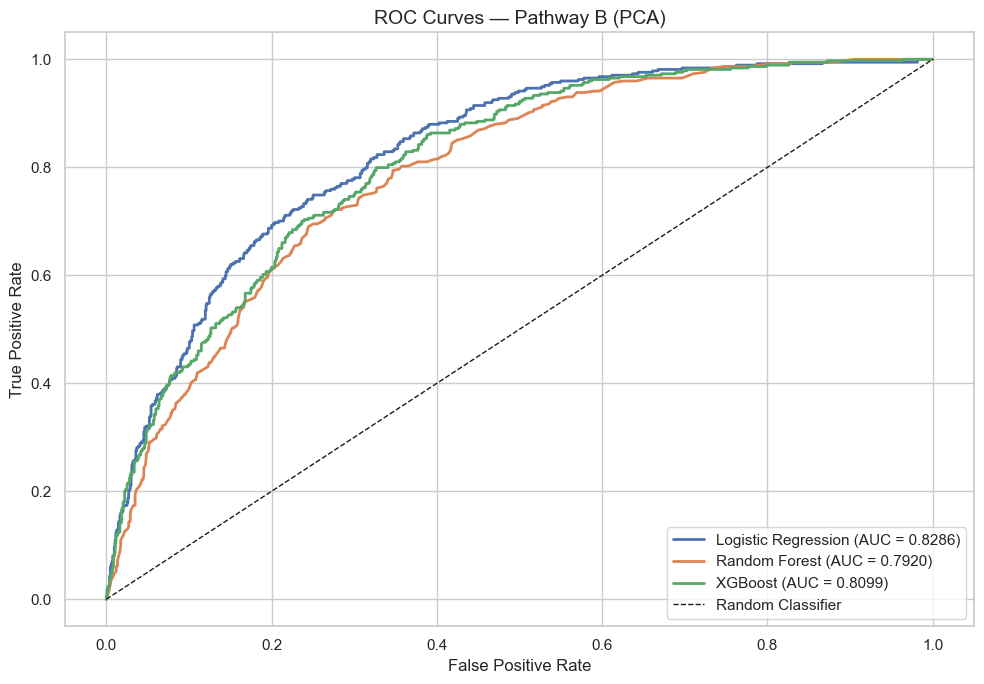

In [13]:
#ROC Curves for Pathway B
plt.figure(figsize=(10, 7))

for name, model in trained_models_pca.items():
    y_proba = model.predict_proba(X_pca_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_pca_test, y_proba)
    auc = roc_auc_score(y_pca_test, y_proba)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc:.4f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier")
plt.title("ROC Curves — Pathway B (PCA)", fontsize=14)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend(loc="lower right", fontsize=11)
plt.tight_layout()
plt.show()

## 5. Pathway Comparison — Feature Selection vs. PCA

We consolidate results from both pathways into a single comparison to determine which feature representation yields better performance for each model.

**Headline finding: Pathway A (Feature Selection) outperforms Pathway B (PCA) on 14 out of 15 metric-model combinations.** The only exception is XGBoost Recall, where PCA scores 0.6497 vs. 0.5909 — but this comes at the expense of Precision and does not translate into a better F1-Score.

**Largest performance gaps (Pathway A advantage):**
- Random Forest Precision: +5.02 points (0.5801 vs. 0.5299)
- XGBoost Precision: +5.14 points (0.5785 vs. 0.5271)
- Random Forest F1-Score: +3.65 points (0.5854 vs. 0.5490)
- Random Forest AUC-ROC: +2.51 points (0.8171 vs. 0.7920)

**Why Pathway A wins:** The PCA transformation discards 10% of explained variance and, more critically, destroys the non-linear feature interactions that tree-based models exploit. Meanwhile, the original features in Pathway A — with only `TotalCharges` removed to prevent multicollinearity — preserve these interactions and retain full business interpretability.

**Best overall configuration: Logistic Regression on Pathway A** (F1 = 0.6128, AUC-ROC = 0.8370). This will serve as the primary baseline for subsequent performance testing and remodelling.

In [14]:
#Build side-by-side comparison table
comparison_rows = []
for model_name in models.keys():
    for metric in ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"]:
        feat_val = results_feat[model_name][metric]
        pca_val = results_pca[model_name][metric]
        comparison_rows.append({
            "Model": model_name,
            "Metric": metric,
            "Pathway A (Features)": round(feat_val, 4),
            "Pathway B (PCA)": round(pca_val, 4),
            "Difference (A - B)": round(feat_val - pca_val, 4)
        })

df_comparison = pd.DataFrame(comparison_rows)
print("=" * 75)
print("FULL COMPARISON — Pathway A (Feature Selection) vs. Pathway B (PCA)")
print("=" * 75)
df_comparison

FULL COMPARISON — Pathway A (Feature Selection) vs. Pathway B (PCA)


,Model,Metric,Pathway A (Features),Pathway B (PCA),Difference (A - B)
0,Logistic Regression,Accuracy,0.7417,0.7374,0.0043
1,Logistic Regression,Precision,0.5088,0.5036,0.0053
2,Logistic Regression,Recall,0.7701,0.7567,0.0134
3,Logistic Regression,F1-Score,0.6128,0.6047,0.0081
4,Logistic Regression,AUC-ROC,0.8370,0.8286,0.0083
5,Random Forest,Accuracy,0.7779,0.7516,0.0263
6,Random Forest,Precision,0.5801,0.5299,0.0502
7,Random Forest,Recall,0.5909,0.5695,0.0214
8,Random Forest,F1-Score,0.5854,0.5490,0.0365
9,Random Forest,AUC-ROC,0.8171,0.7920,0.0251


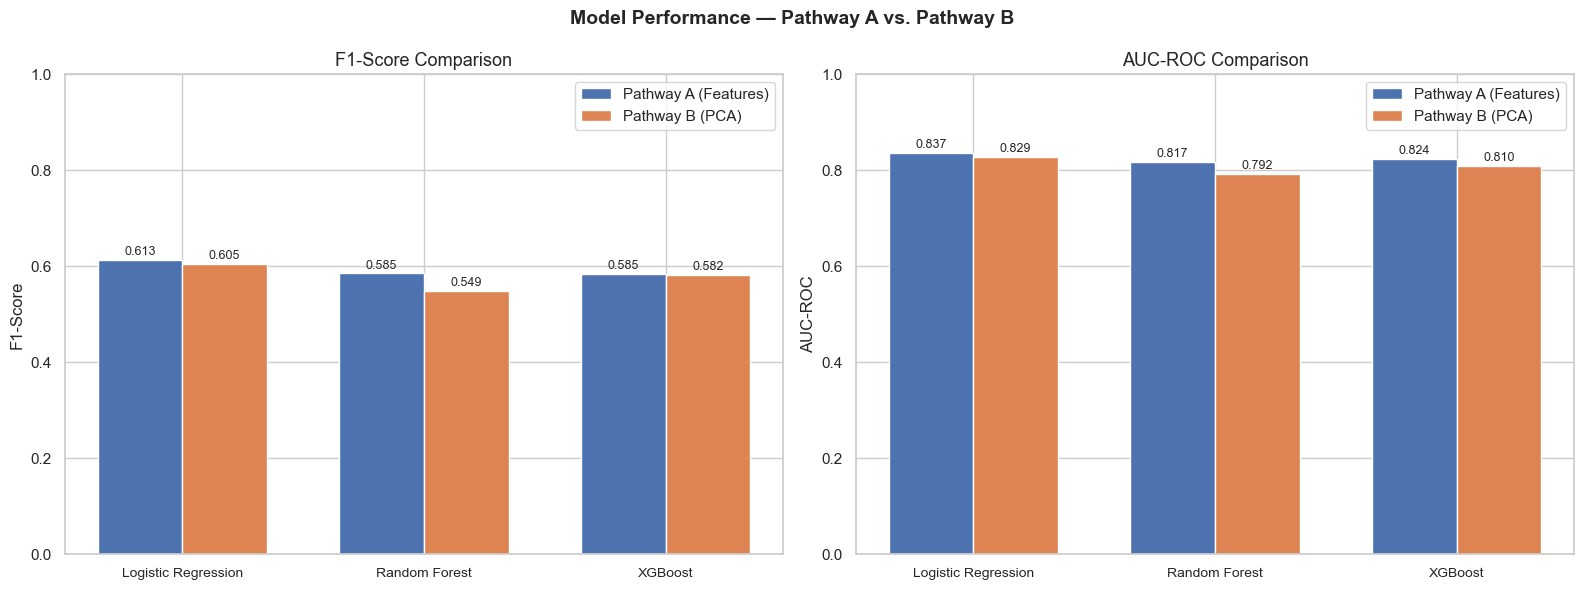

In [15]:
#Visual comparison: F1-Score and AUC-ROC side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_names = list(models.keys())
x = np.arange(len(model_names))
bar_width = 0.35

#F1-Score comparison
f1_feat = [results_feat[m]["F1-Score"] for m in model_names]
f1_pca = [results_pca[m]["F1-Score"] for m in model_names]

axes[0].bar(x - bar_width/2, f1_feat, bar_width, label="Pathway A (Features)", color="#4C72B0")
axes[0].bar(x + bar_width/2, f1_pca, bar_width, label="Pathway B (PCA)", color="#DD8452")
axes[0].set_title("F1-Score Comparison", fontsize=13)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, fontsize=10)
axes[0].set_ylabel("F1-Score")
axes[0].set_ylim(0, 1)
axes[0].legend()

#Add value labels
for i, (v1, v2) in enumerate(zip(f1_feat, f1_pca)):
    axes[0].text(i - bar_width/2, v1 + 0.01, f"{v1:.3f}", ha="center", fontsize=9)
    axes[0].text(i + bar_width/2, v2 + 0.01, f"{v2:.3f}", ha="center", fontsize=9)

#AUC-ROC comparison
auc_feat = [results_feat[m]["AUC-ROC"] for m in model_names]
auc_pca = [results_pca[m]["AUC-ROC"] for m in model_names]

axes[1].bar(x - bar_width/2, auc_feat, bar_width, label="Pathway A (Features)", color="#4C72B0")
axes[1].bar(x + bar_width/2, auc_pca, bar_width, label="Pathway B (PCA)", color="#DD8452")
axes[1].set_title("AUC-ROC Comparison", fontsize=13)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, fontsize=10)
axes[1].set_ylabel("AUC-ROC")
axes[1].set_ylim(0, 1)
axes[1].legend()

#Add value labels
for i, (v1, v2) in enumerate(zip(auc_feat, auc_pca)):
    axes[1].text(i - bar_width/2, v1 + 0.01, f"{v1:.3f}", ha="center", fontsize=9)
    axes[1].text(i + bar_width/2, v2 + 0.01, f"{v2:.3f}", ha="center", fontsize=9)

plt.suptitle("Model Performance — Pathway A vs. Pathway B", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Feature Importance — Pathway A

Since Pathway A retains the original interpretable features, we can extract feature importance from the tree-based models and coefficients from Logistic Regression. This is essential for generating business insights about what drives customer churn.

**Insights from the feature importance plots:**

**Logistic Regression coefficients** reveal the direction of influence:
- **Strongest churn drivers (positive coefficients):** `Contract_Two year` and `tenure` have the largest negative coefficients (protective against churn), while `MonthlyCharges`, `InternetService_Fiber optic`, and `PaymentMethod_Electronic check` have the largest positive coefficients (increasing churn risk).
- This aligns with the EDA findings: month-to-month contracts, fiber optic internet, and electronic check payments were associated with the highest churn rates.

**Random Forest & XGBoost importance** (based on information gain / impurity reduction):
- Both tree-based models consistently rank **`tenure`**, **`MonthlyCharges`**, and **`Contract_Two year`** as the top 3 most important features.
- The agreement across all three model types strengthens confidence that these features are genuine churn drivers and not artifacts of a single algorithm.

**Business implication:** Retention strategies should prioritise incentivising longer contracts, addressing pricing concerns for high-spend customers, and encouraging automatic payment methods over electronic checks. These actionable levers are only available because Pathway A preserves the original feature semantics.

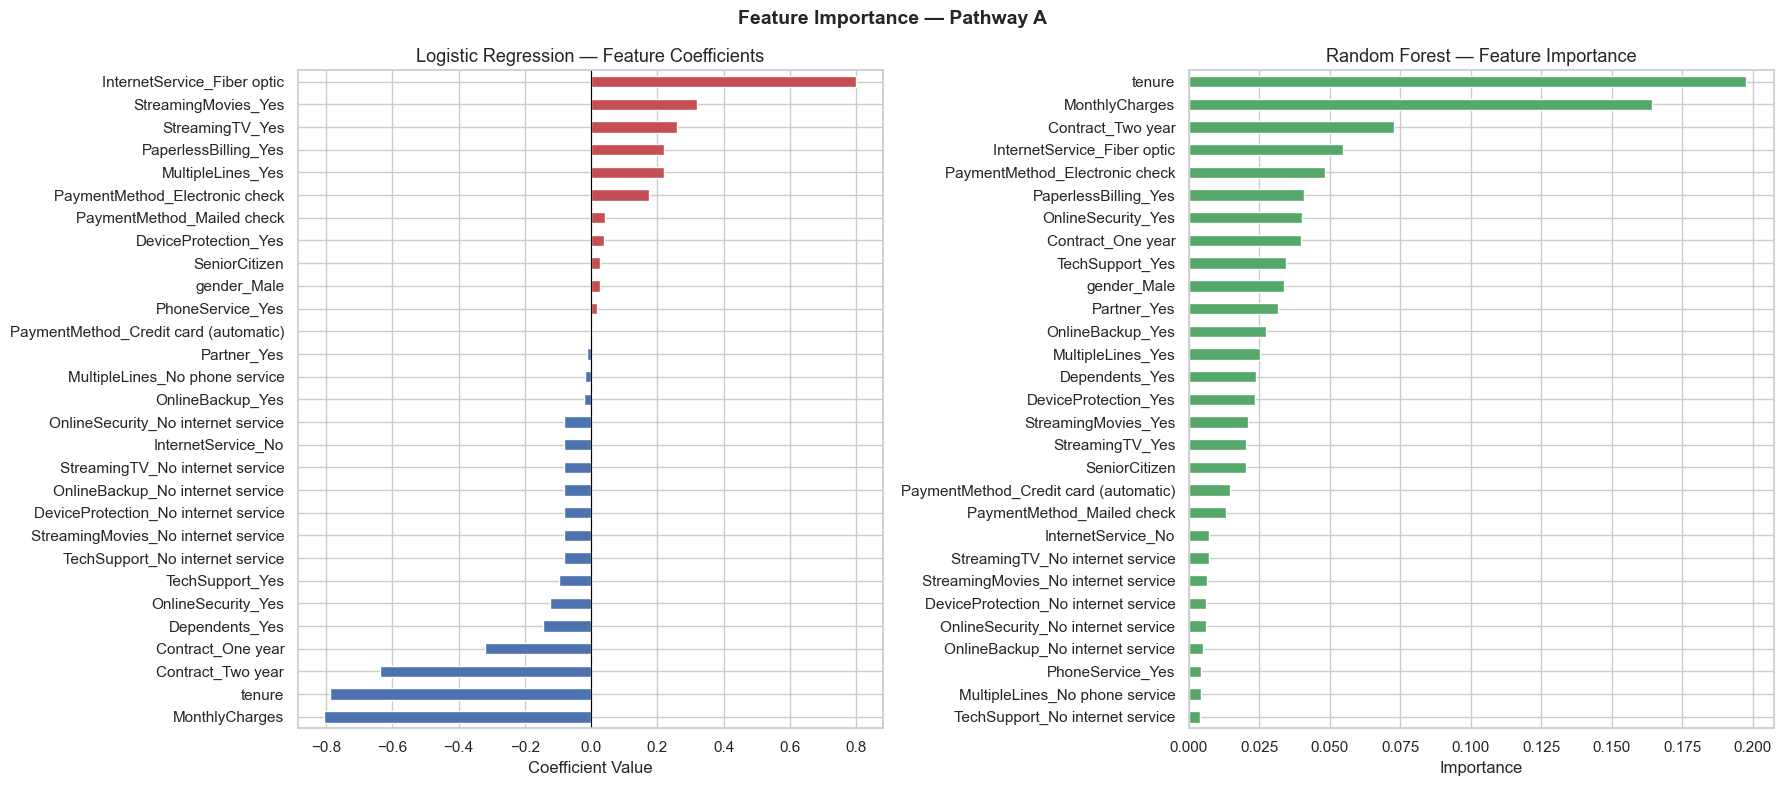

In [16]:
#Feature Importance: Logistic Regression (coefficients)
lr_model = trained_models_feat["Logistic Regression"]
lr_importance = pd.Series(lr_model.coef_[0], index=X_feat.columns).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

#Top positive and negative coefficients
lr_importance.plot(kind="barh", ax=axes[0], color=lr_importance.apply(lambda x: "#C44E52" if x > 0 else "#4C72B0"))
axes[0].set_title("Logistic Regression — Feature Coefficients", fontsize=13)
axes[0].set_xlabel("Coefficient Value")
axes[0].axvline(x=0, color="black", linewidth=0.8)

#Feature Importance: Random Forest
rf_model = trained_models_feat["Random Forest"]
rf_importance = pd.Series(rf_model.feature_importances_, index=X_feat.columns).sort_values(ascending=True)

rf_importance.plot(kind="barh", ax=axes[1], color="#55A868")
axes[1].set_title("Random Forest — Feature Importance", fontsize=13)
axes[1].set_xlabel("Importance")

plt.suptitle("Feature Importance — Pathway A", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

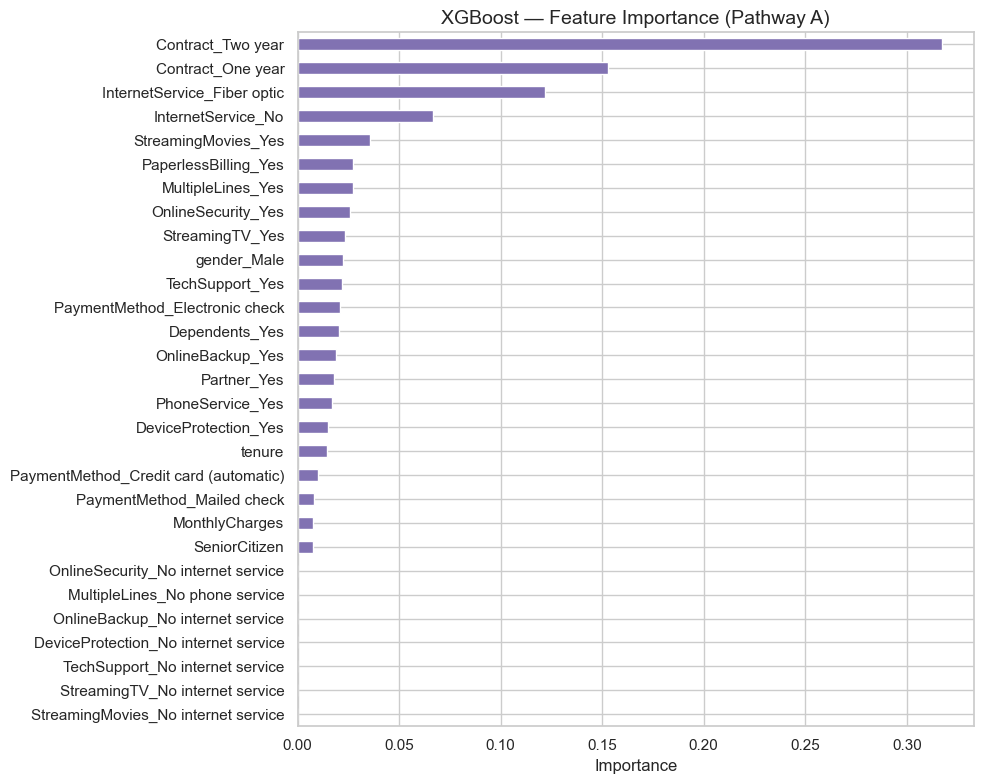

In [17]:
#Feature Importance: XGBoost
xgb_model = trained_models_feat["XGBoost"]
xgb_importance = pd.Series(xgb_model.feature_importances_, index=X_feat.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
xgb_importance.plot(kind="barh", color="#8172B2")
plt.title("XGBoost — Feature Importance (Pathway A)", fontsize=14)
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 7. Export Results for Subsequent Notebooks

We save the comparison results and trained model objects so they can be loaded directly in the upcoming **Performance & Testing** and **Remodelling** notebooks without retraining.

In [18]:
import joblib

#Export trained models for reuse in subsequent notebooks
joblib.dump(trained_models_feat, "trained_models_features.pkl")
joblib.dump(trained_models_pca, "trained_models_pca.pkl")

#Export test sets for consistent evaluation in subsequent notebooks
joblib.dump({
    "X_feat_test": X_feat_test, "y_feat_test": y_feat_test,
    "X_feat_train_sm": X_feat_train_sm, "y_feat_train_sm": y_feat_train_sm,
    "X_pca_test": X_pca_test, "y_pca_test": y_pca_test,
    "X_pca_train_sm": X_pca_train_sm, "y_pca_train_sm": y_pca_train_sm
}, "train_test_splits.pkl")

#Export comparison results
df_comparison.to_csv("model_comparison_results.csv", index=False)
df_results_feat.to_csv("pathway_a_results.csv")
df_results_pca.to_csv("pathway_b_results.csv")

print("Exported artifacts:")
print("  • trained_models_features.pkl  — Pathway A trained models")
print("  • trained_models_pca.pkl       — Pathway B trained models")
print("  • train_test_splits.pkl        — Train/test data splits")
print("  • model_comparison_results.csv — Full comparison table")
print("  • pathway_a_results.csv        — Pathway A metrics")
print("  • pathway_b_results.csv        — Pathway B metrics")

Exported artifacts:
  • trained_models_features.pkl  — Pathway A trained models
  • trained_models_pca.pkl       — Pathway B trained models
  • train_test_splits.pkl        — Train/test data splits
  • model_comparison_results.csv — Full comparison table
  • pathway_a_results.csv        — Pathway A metrics
  • pathway_b_results.csv        — Pathway B metrics


## Conclusion & Next Steps

This notebook established baseline models for both data pathways using Logistic Regression, Random Forest, and XGBoost. All models were trained on SMOTE-balanced training data (4,139 samples per class) and evaluated on the original imbalanced test set (1,409 samples) to reflect real-world conditions.

### Key Findings

**1. Pathway A (Feature Selection) is the clear winner.**
It outperforms Pathway B (PCA) on 14 out of 15 metric-model combinations. The 10% variance lost through PCA degraded performance across all models, with tree-based models (Random Forest, XGBoost) suffering the most. Pathway A also retains full business interpretability — a critical advantage for actionable churn reduction strategies.

**2. Logistic Regression is the best-performing baseline model.**
With an F1-Score of **0.6128** and AUC-ROC of **0.8370** on Pathway A, it outperforms both tree-based models. Its high Recall (77%) makes it especially suited for churn prevention, where catching at-risk customers is more valuable than minimising false alarms.

**3. Top churn drivers confirmed across all models:**
- **`tenure`** — shorter tenure strongly predicts churn
- **`MonthlyCharges`** — higher charges increase churn risk
- **`Contract_Two year`** — long-term contracts are strongly protective
- **`InternetService_Fiber optic`** and **`PaymentMethod_Electronic check`** — both increase churn risk

**4. Current model limitations:**
- All models show moderate Precision (~0.51–0.58 for churn class), meaning a significant portion of predicted churners are actually non-churners. Threshold tuning in the next notebook may improve this trade-off.
- Random Forest and XGBoost have not been hyperparameter-tuned yet — their default configurations may not reflect their full potential.

### Artifacts Exported
- `trained_models_features.pkl` / `trained_models_pca.pkl` — trained model objects
- `train_test_splits.pkl` — train/test data for consistent evaluation
- `pathway_a_results.csv` / `pathway_b_results.csv` / `model_comparison_results.csv` — metrics tables

### Next Steps
1. **Notebook 05 — Performance & Testing:** Cross-validation, threshold tuning, statistical significance testing, and deeper error analysis to validate and refine these baseline results.
2. **Notebook 06 — Remodelling:** Hyperparameter tuning (GridSearch/RandomizedSearch), ensemble strategies, and final model selection with business recommendations.